# EDA: priorización de proyectos de IA

**Objetivo del ejercicio:** explorar los datos estadísticamente con el enfoque de entrenar un modelo con el conjunto **historical** (`historical_ai_projects.csv`, con `implementation_success` conocido) para predecir `implementation_success` en el conjunto **catalog** (`process_catalog.csv`, sin etiqueta).

Este notebook recorre paso a paso:

1. Configuración y carga de datos
2. Distribuciones de las variables
3. Conclusiones y siguientes pasos

## 1. Configuración y carga de datos

In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

#! Configuración de opciones
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

#! Configuración de constantes
PATH_CATALOG = "../data/outputs/1A_process_catalog.csv"
PATH_HIST = "../data/outputs/1A_historical_ai_projects.csv"
TARGET = "implementation_success"

COLORES = {"historical": "#C44E52", "catalog": "#4C72B0"}

In [68]:
# Carga de datos y visualización de información básica
catalog = pd.read_csv(PATH_CATALOG)
historical = pd.read_csv(PATH_HIST)

print(f"catalog : {catalog.shape[0]} filas x {catalog.shape[1]} columnas")
print(f"historical: {historical.shape[0]} filas x {historical.shape[1]} columnas")

print("\nCatalog (primeras filas)")
display(catalog.head())
print("Historical (primeras filas)")
display(historical.head())

catalog : 300 filas x 13 columnas
historical: 160 filas x 14 columnas

Catalog (primeras filas)


,process_id,department,process_name,monthly_volume,avg_minutes,manual_share,data_availability,process_complexity,annual_hours,automation_potential,recoverable_hours,estimated_annual_benefit,feasibility_score
0,P0001,IT,Invoice validation,252,31.400,0.537,3,5,"1,582.560",0.449,709.780,"21,293,345.000",0.360
1,P0002,Sales,Invoice validation,256,59.600,0.798,2,5,"3,051.520",0.519,"1,583.740","47,512,166.000",0.240
2,P0003,Human Resources,Customer data entry,425,14.000,0.696,3,2,"1,190.000",0.648,771.120,"23,133,600.000",0.600
3,P0004,IT,Data consolidation,90,33.500,0.947,4,3,603.000,0.793,478.480,"14,354,415.000",0.640
4,P0005,Customer Service,Monthly reporting,703,32.500,0.621,3,5,"4,569.500",0.490,"2,241.340","67,240,192.000",0.360


Historical (primeras filas)


,project_id,department,process_name,monthly_volume,avg_minutes,manual_share,data_availability,process_complexity,implementation_success,annual_hours,automation_potential,recoverable_hours,estimated_annual_benefit,feasibility_score
0,H0001,Operations,Customer onboarding,315,28.500,0.683,1,4,0,"1,795.500",0.442,792.710,"23,781,398.000",0.200
1,H0002,Procurement,Data consolidation,184,9.800,0.886,1,5,0,360.640,0.503,181.400,"5,442,058.000",0.120
2,H0003,Procurement,Monthly reporting,224,18.900,0.809,4,1,1,846.720,0.804,681.190,"20,435,587.000",0.800
3,H0004,Operations,Data consolidation,328,13.000,0.879,5,1,1,852.800,0.899,767.090,"23,012,808.000",0.920
4,H0005,IT,Customer data entry,164,8.500,0.709,5,1,1,278.800,0.815,227.080,"6,812,478.000",0.920


## 2. Distribuciones de las variables originales

### 2.1 Estadísticos descriptivos

In [69]:
# Estadísticas descriptivas numéricas de los DataFrames de catálogo e histórico
print("Catalog")
display(catalog.describe())

print("Historical")
display(historical.describe())

Catalog


,monthly_volume,avg_minutes,manual_share,data_availability,process_complexity,annual_hours,automation_potential,recoverable_hours,estimated_annual_benefit,feasibility_score
count,300.000,300.000,300.000,300.000,300.000,300.000,300.000,300.000,300.000,300.000
mean,477.373,26.696,0.693,3.017,2.903,"2,563.719",0.611,"1,555.776","46,673,261.757",0.530
std,436.064,19.283,0.156,1.436,1.419,"3,313.154",0.124,"2,057.850","61,735,499.040",0.206
min,36.000,2.000,0.182,1.000,1.000,31.680,0.256,13.960,"418,651.000",0.120
25%,203.500,13.000,0.589,2.000,2.000,709.740,0.519,389.305,"11,679,126.750",0.360
50%,329.000,23.100,0.696,3.000,3.000,"1,315.670",0.613,783.550,"23,506,471.500",0.560
75%,624.250,34.350,0.810,4.000,4.000,"3,133.335",0.693,"1,893.803","56,814,078.000",0.680
max,"3,062.000",114.700,0.982,5.000,5.000,"24,128.560",0.890,"15,599.110","467,973,421.000",0.920


Historical


,monthly_volume,avg_minutes,manual_share,data_availability,process_complexity,implementation_success,annual_hours,automation_potential,recoverable_hours,estimated_annual_benefit,feasibility_score
count,160.000,160.000,160.000,160.000,160.000,160.000,160.000,160.000,160.000,160.000,160.000
mean,388.812,21.815,0.701,3.269,3.138,0.450,"1,728.858",0.621,"1,027.445","30,823,357.931",0.541
std,202.903,10.628,0.158,1.422,1.473,0.499,"1,349.898",0.146,736.801,"22,104,035.751",0.219
min,57.000,6.000,0.245,1.000,1.000,0.000,243.960,0.262,146.320,"4,389,746.000",0.120
25%,261.750,14.875,0.591,2.000,2.000,0.000,836.175,0.506,531.680,"15,950,523.750",0.400
50%,323.000,19.600,0.711,3.000,3.000,0.000,"1,424.110",0.625,794.360,"23,830,768.500",0.520
75%,482.250,25.550,0.827,5.000,4.250,1.000,"2,206.940",0.716,"1,344.905","40,347,151.250",0.680
max,"1,079.000",62.400,0.997,5.000,5.000,1.000,"8,136.960",0.959,"4,411.570","132,347,134.000",0.920


In [70]:
# Estadísticas descriptivas de los DataFrames de catálogo e histórico para columnas de tipo objeto
print("Catalog")
display(catalog.describe(include='object'))

print("Historical")
display(historical.describe(include='object'))

Catalog


,process_id,department,process_name
count,300,300,300
unique,300,8,15
top,P0300,Sales,Invoice validation
freq,1,46,28


Historical


,project_id,department,process_name
count,160,160,160
unique,160,8,15
top,H0001,Procurement,Data consolidation
freq,1,28,17


### 2.2 Comparación de distribuciones: historical vs catalog

El modelo se entrena con historical y se aplica a catalog, así que es clave que ambos conjuntos se parezcan. Si una variable se distribuye muy distinto, el modelo se enfrentaría a datos fuera de lo visto en entrenamiento (*data drift*). Las barras están normalizadas por densidad para poder comparar conjuntos de distinto tamaño.

In [71]:
# Selección de características y categorización de columnas
features = [col for col in catalog.columns if col not in [TARGET, "process_id", "proyect_id"]]
numerical_features = ["monthly_volume", "avg_minutes", "manual_share", "data_availability", "process_complexity", "annual_hours", "automation_potential", "recoverable_hours", "estimated_annual_benefit", "feasibility_score"]
categorical_features = ["department", "process_name"]
id_columns = ["process_id", "proyect_id"]

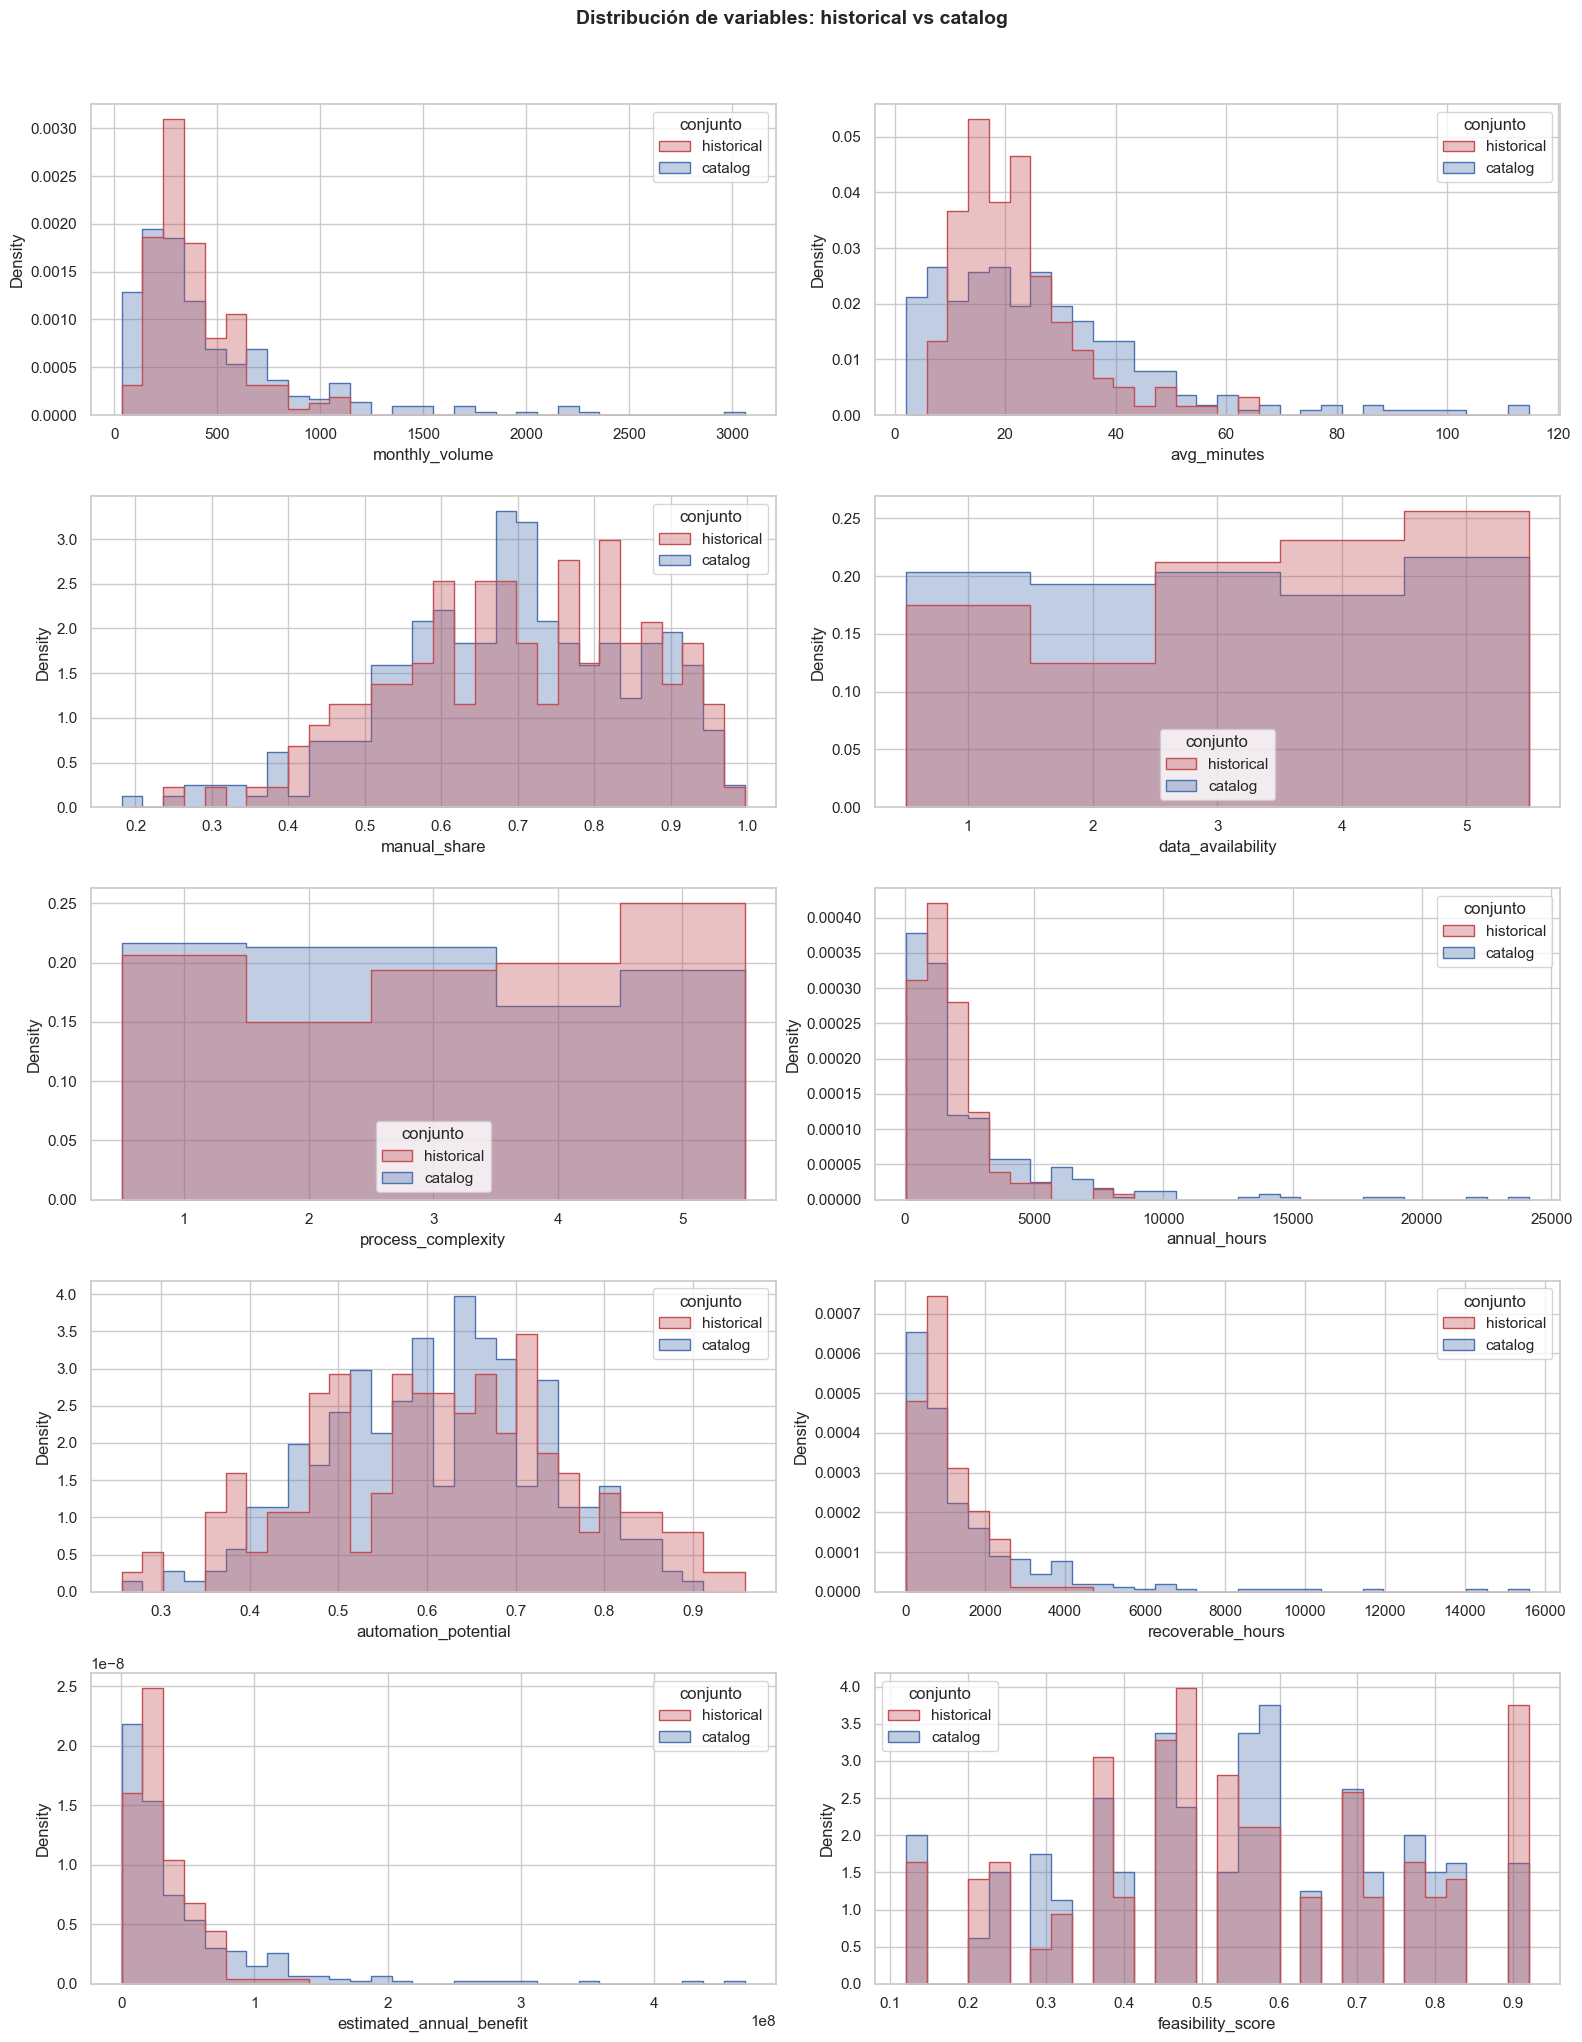

In [72]:
# Comparación de la distribución de variables numéricas entre los DataFrames históricos y de catálogo

# Combinar los DataFrames históricos y de catálogo en uno solo para facilitar la comparación
combinado = pd.concat(
    [historical.assign(conjunto="historical"), catalog.assign(conjunto="catalog")],
    ignore_index=True,
)

# Visualización de la distribución de variables numéricas
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
for ax, col in zip(axes.ravel(), numerical_features):
    discreta = col in ["data_availability", "process_complexity"]
    kw = {"discrete": True} if discreta else {"bins": 30}
    sns.histplot(
        data=combinado, x=col, hue="conjunto", palette=COLORES, stat="density",
        common_norm=False, element="step", alpha=0.35, ax=ax,
         **kw,
    )

fig.suptitle("Distribución de variables: historical vs catalog", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

- La visualización muestra que `historical` y `catalog` tienen distribuciones similares en `manual_share`, `data_availability` y `process_complexity`, lo que favorece la aplicación del modelo; sin embargo, `catalog` presenta valores más extremos en `monthly_volume` y `avg_minutes`, por lo que algunas predicciones implicarán extrapolación.
- En `historical`, se destacan mayores proyectos con alta la disponibilidad de datos y alta complejidad del proceso, es probable que esto último se relacione con su baja tasa de exito.

### 2.3 Variables categóricas

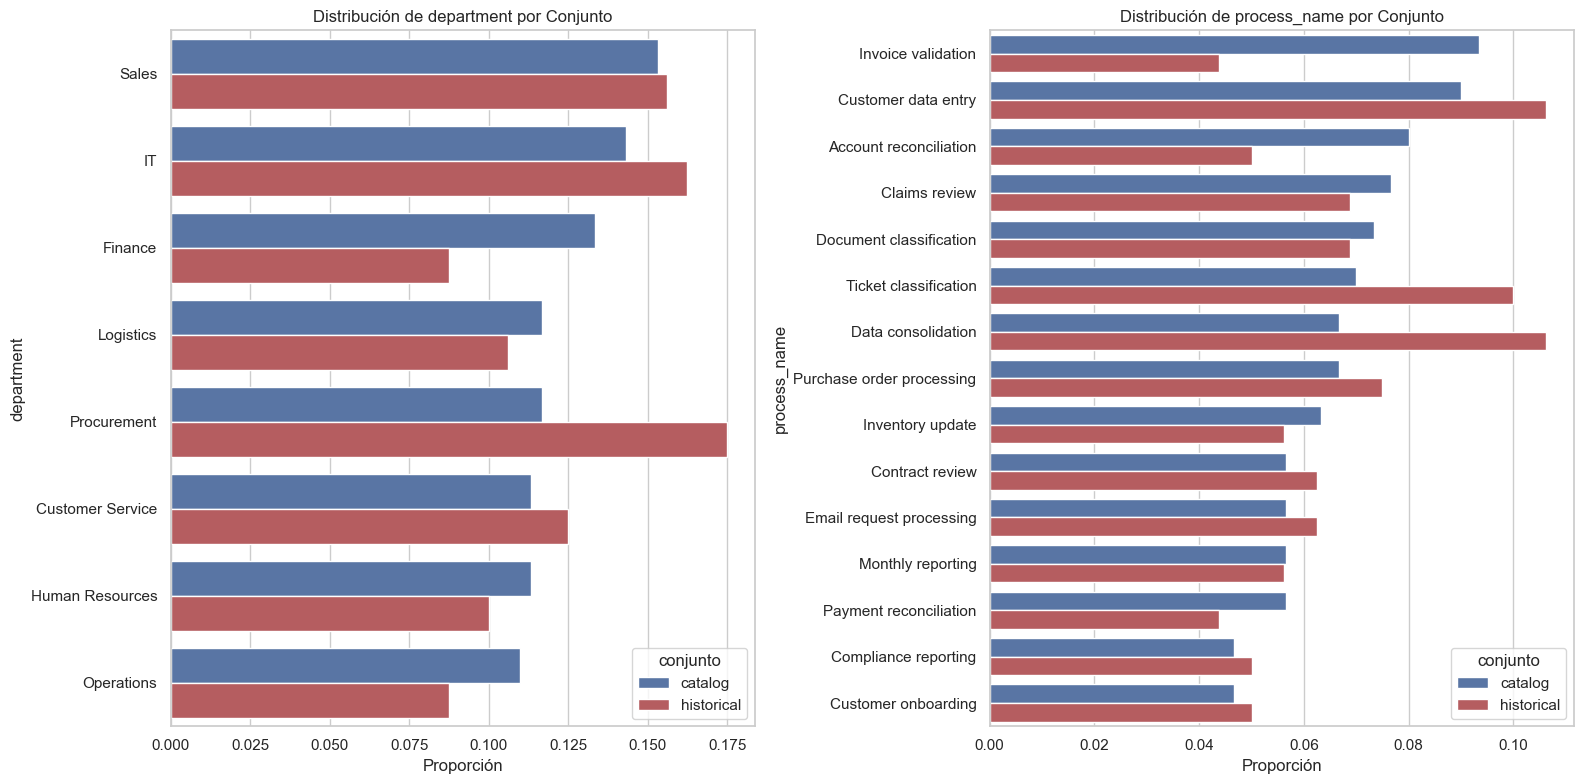

In [85]:

# Visualizar en un grafico de barras la distribución porcentual de departamentos y procesos por conjunto
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Iterar sobre las características categóricas y visualizar su distribución porcentual por conjunto
for ax, col in zip(axes.ravel(), categorical_features):
    distribution = pd.DataFrame(combinado.groupby("conjunto")[col].value_counts()/combinado.groupby("conjunto")[col].value_counts().groupby(level=0).sum())
    distribution.columns = ["count"]
    sns.barplot(data=distribution, x="count", y=distribution.index.get_level_values(1), hue=distribution.index.get_level_values(0), ax=ax, palette=COLORES)
    ax.set_title(f"Distribución de {col} por Conjunto")
    ax.set_ylabel(col)
    ax.set_xlabel("Proporción")
    
 
plt.tight_layout()
plt.show()

Hay una diferencia entre los dos conjuntos para la distribución de los departamentos de `Procurement` y `Finance⁣`; aun así, todos los departamentos tienen buena representación en ambos conjuntos. Lo mismo sucede en los nombres de los procesos para  `Invoice validation`, `Account reconciliation`, `Ticket classification` y `Data consolidation`.

### 2.4 Balance de clases

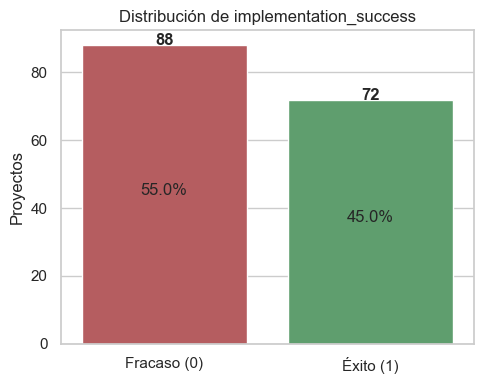

In [74]:
# Distribución de la variable objetivo `implementation_success`
conteo = historical[TARGET].value_counts().sort_index()
porc = (conteo / conteo.sum() * 100).round(1)

# Conteo y porcentaje de cada clase
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=["Fracaso (0)", "Éxito (1)"], y=conteo.values, palette=["#C44E52", "#55A868"], ax=ax)
for i, (n, p) in enumerate(zip(conteo.values, porc.values)):
    ax.text(i, n, f"{n}", ha="center", fontweight="bold")
    ax.text(i, n/2, f"{p}%", ha="center")
ax.set_title("Distribución de implementation_success")
ax.set_ylabel("Proyectos")

plt.tight_layout()
plt.show()

La variable `implementation_success` presenta un desbalance leve: 88 proyectos fallidos (55 %) frente a 72 exitosos (45 %). La diferencia no es suficientemente grande para requerir técnicas de remuestreo.

### 2.5 Tasa de éxito por nivel de las variables ordinales

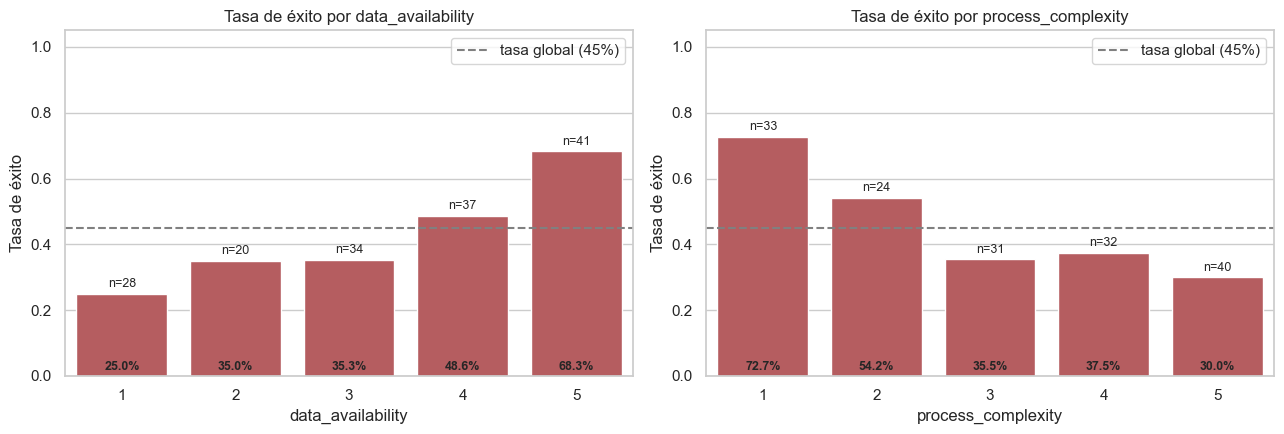

In [105]:

# Calcular la tasa de éxito global
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
tasa_global = historical[TARGET].mean()

# Tasa de éxito por disponibilidad de datos y complejidad del proceso
for ax, col in zip(axes, ["data_availability", "process_complexity"]):
    tasa = historical.groupby(col)[TARGET].agg(["mean", "count"]).reset_index()
    sns.barplot(data=tasa, x=col, y="mean", color=COLORES["historical"], ax=ax)
    for i, fila in tasa.iterrows():
        ax.text(i, fila["mean"] + 0.02, f"n={int(fila['count'])}", ha="center", fontsize=9)
        ax.text(i, 0.01, f"{fila["mean"]:.1%}", ha="center",va="bottom", fontsize=9, fontweight="bold")
    ax.axhline(tasa_global, color="gray", linestyle="--", label=f"tasa global ({tasa_global:.0%})")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Tasa de éxito")
    ax.set_title(f"Tasa de éxito por {col}")
    ax.legend(loc="upper right")
    
plt.tight_layout()
plt.show()

Se puede ver una correlación directamente proporcional con la disponibilidad e inversamente proporcional con la complejidad, respecto a la variable objetivo.

### 2.6 Variables continuas según el resultado

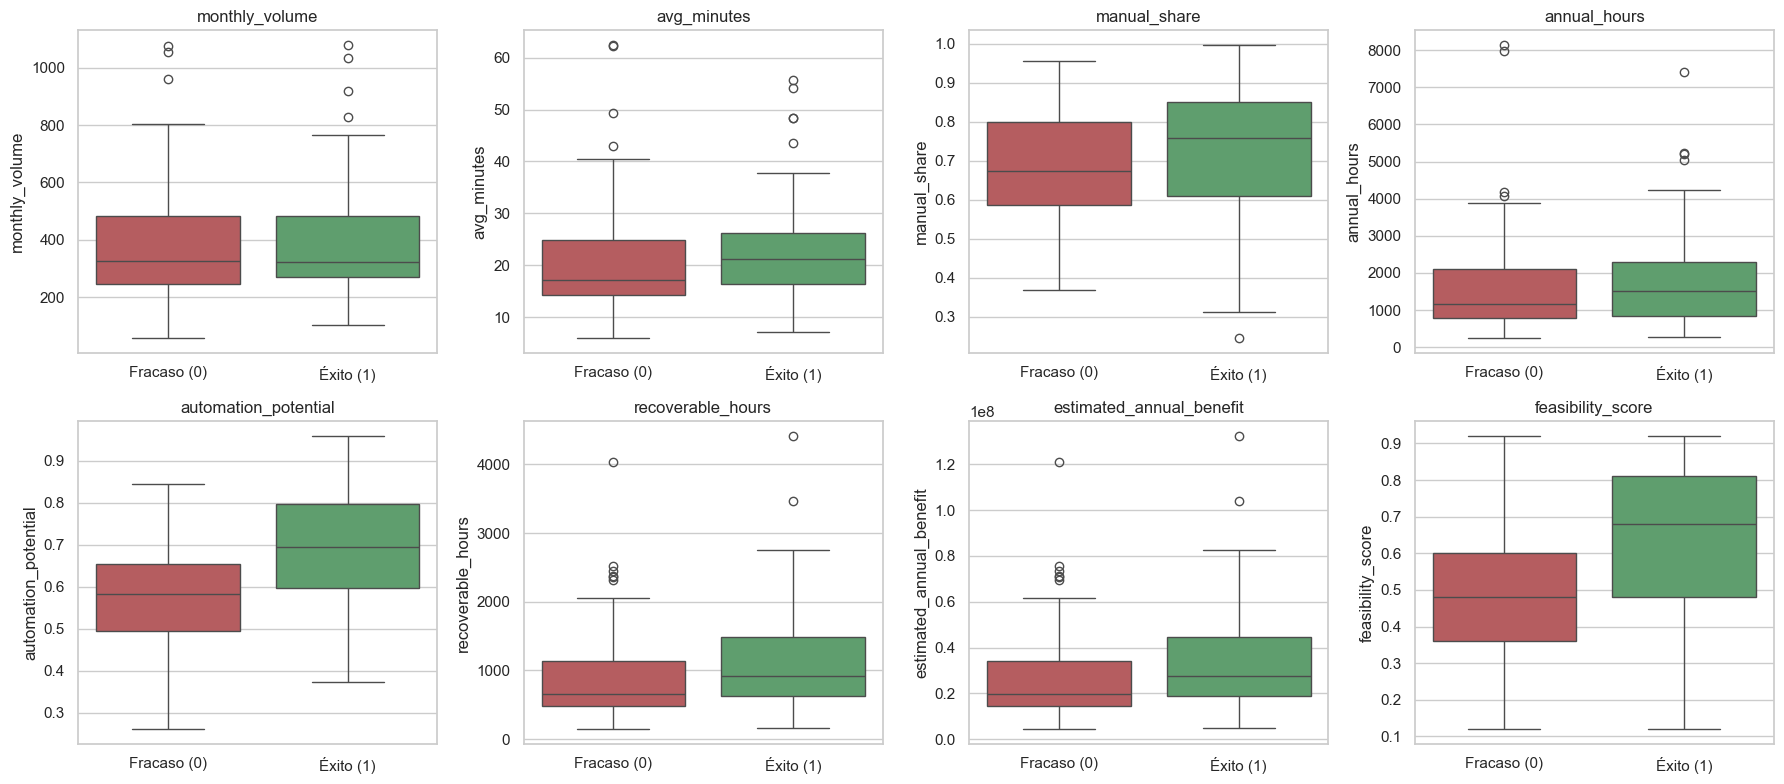

In [76]:
# Lista de variables continuas para análisis exploratorio de datos (EDA)
cont = ["monthly_volume", "avg_minutes", "manual_share", "annual_hours", "automation_potential", 
        "recoverable_hours", "estimated_annual_benefit", "feasibility_score"]

# Visualización de distribuciones de variables continuas mediante boxplots segmentados por la variable objetivo
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), cont):
    sns.boxplot(data=historical, x=TARGET, y=col, palette=["#C44E52", "#55A868"], ax=ax)
    
    ax.set_xticklabels(["Fracaso (0)", "Éxito (1)"])
    ax.set_xlabel("")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Los proyectos exitosos tienden a presentar mayores valores de `automation_potential`, `recoverable_hours`, `estimated_annual_benefit` y `feasibility_score` que los proyectos fallidos. La separación es especialmente visible en `feasibility_score`, lo que sugiere que esta variable puede ser un predictor relevante de `implementation_success`.

En cambio, `monthly_volume`, `avg_minutes`, `manual_share` y `annual_hours` muestran una considerable superposición entre ambas clases. Por tanto, individualmente parecen discriminar poco entre proyectos exitosos y fallidos. También se observan valores extremos y distribuciones sesgadas, especialmente en las variables relacionadas con horas y beneficios, por lo que podría ser conveniente aplicar transformaciones logarítmicas en modelos lineales.

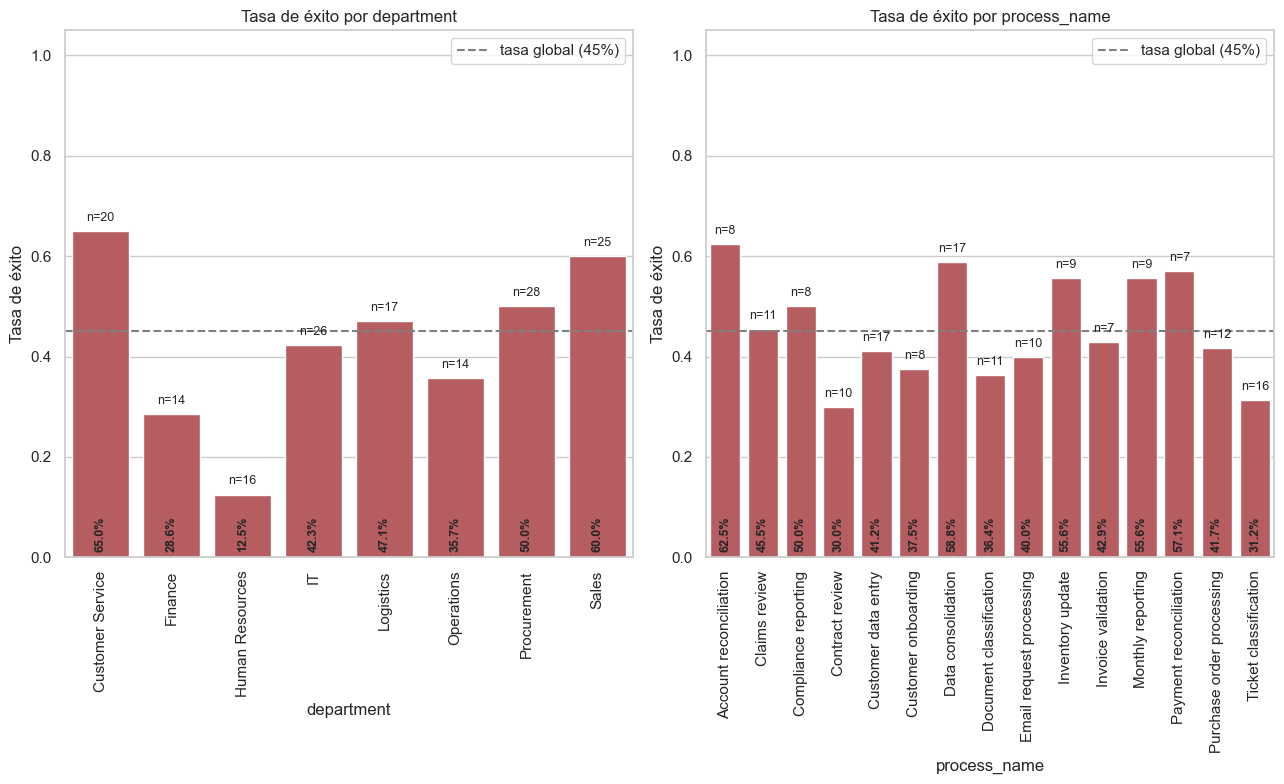

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(13, 8))

# Visualizacion del porcentaje de exito de las variables categoricas department y process_name
for ax, col in zip(axes, categorical_features):
    tasa = historical.groupby(col)[TARGET].agg(["mean", "count"]).reset_index()
    sns.barplot(data=tasa, x=col, y="mean", color=COLORES["historical"], ax=ax)
    for i, fila in tasa.iterrows():
        ax.text(i, fila["mean"] + 0.02, f"n={int(fila['count'])}", ha="center", fontsize=9)
        ax.text(i, 0.01, f"{fila["mean"]:.1%}", ha="center",va="bottom", fontsize=9, rotation=90, fontweight="bold")
    ax.axhline(tasa_global, color="gray", linestyle="--", label=f"tasa global ({tasa_global:.0%})")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Tasa de éxito")
    ax.set_title(f"Tasa de éxito por {col}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.legend(loc="upper right")
        
plt.tight_layout()
plt.show()


- La tasa de éxito varía entre departamentos y nombres de proceso, por lo que ambas variables podrían aportar información al modelo.
- Algunas categorías presentan tasas superiores a la media global del 45 %, mientras que otras se encuentran por debajo.
- Las diferencias deben interpretarse con cautela, especialmente en categorías con pocos proyectos, ya que sus tasas pueden ser menos estables.
- department puede incorporarse a un modelo lineal mediante codificación OHE por tener menos etiquetas que process_name, ambas caracteriscticas pueden ser usadas en un modelo de bosque.

## 3. Conclusiones y siguientes pasos

**Calidad de datos**
- Ninguno de los dos conjuntos tiene nulos ni duplicados, los identificadores son únicos y todas las variables están dentro de sus rangos válidos.

**Objetivo (historical)**
- Hay 72 proyectos exitosos (45 %) y 88 fallidos (55 %): el desbalance es leve y no requiere remuestreo, pero conviene usar validación estratificada.

**¿Se parecen historical y catalog?**
- `manual_share`, `data_availability` y `process_complexity` tienen distribuciones estadísticamente similares.
- `monthly_volume` y `avg_minutes` sí difieren: catalog tiene colas más largas. Lo mismo ocurre con `annual_hours`, `recoverable_hours` y `estimated_annual_benefit`, aunque sus medianas son casi iguales. Al predecir en catalog, el modelo verá procesos más grandes que los de su entrenamiento.

**Qué se relaciona con el éxito**
- La señal está en la viabilidad: `feasibility_score`, `automation_potential`, `data_availability` y `process_complexity`.
- `recoverable_hours` y `estimated_annual_benefit` tienen una relación débil.
- `monthly_volume y `avg_minutes` no muestran relación con el éxito. `manual_share` muestra algo marginal.

**Limitaciones**
- Con 160 proyectos, se tienen pocos datos para modelos complejos, por lo que se recomienda priorizar modelos simples.

**Siguientes pasos**
1. Modelo base con regresión logística sobre un conjunto sin redundancias (por ejemplo OHE(`department`), `data_availability`, `process_complexity`, `manual_share` y `log(annual_hours)`), y compararlo con un modelo de árboles (Random Forest) que use todas las variables.
2. Midiendo F1 y ROC-AUC. Para mantener un balance de precisión y recall.